In [1]:
import pandas as pd

In [2]:
nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")
perf = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")

print(nav.columns)
print(benchmark.columns)
print(perf.columns)

Index(['amfi_code', 'date', 'nav'], dtype='str')
Index(['date', 'index_name', 'close_value'], dtype='str')
Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='str')


In [3]:
benchmark["index_name"].unique()


<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

# Daily Return Analysis

In [4]:
#Load NAV Data

import pandas as pd
import numpy as np

nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")

nav["date"] = pd.to_datetime(nav["date"])

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [5]:
# Calculate Daily Returns

nav = nav.sort_values(["amfi_code", "date"])

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [6]:
#Verify Results

nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

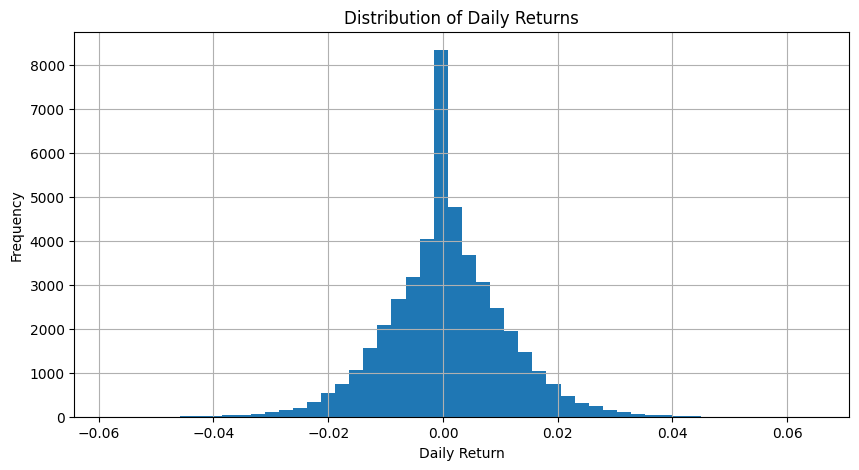

In [7]:
#Distribution Chart

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

nav["daily_return"].dropna().hist(
    bins=50
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

In [8]:
#Save Deliverable

nav.to_csv(
    "../data/processed/returns_computed.csv",
    index=False
)

print("returns_computed.csv created")

returns_computed.csv created


### Observation

- Daily returns are centered around zero, indicating normal day-to-day market fluctuations.
- Most returns fall within a narrow range, while extreme gains and losses occur less frequently.
- The return distribution resembles a bell-shaped pattern with occasional outliers.
- Daily return calculations form the foundation for risk and performance metrics such as CAGR, Sharpe Ratio, Sortino Ratio, Alpha, and Beta.

In [9]:
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

# CAGR Analysis

In [10]:
#Latest NAV

latest_date = nav["date"].max()

print(latest_date)

2026-05-29 00:00:00


In [11]:
#CAGR Function

def calculate_cagr(start_nav, end_nav, years):
    return ((end_nav / start_nav) ** (1 / years) - 1) * 100

In [12]:
#Calculate CAGR for Every Fund

cagr_results = []

for fund in nav["amfi_code"].unique():

    fund_data = nav[nav["amfi_code"] == fund].sort_values("date")

    try:
        latest_nav = fund_data.iloc[-1]["nav"]

        nav_1yr = fund_data.iloc[-252]["nav"]
        nav_3yr = fund_data.iloc[-756]["nav"]
        nav_5yr = fund_data.iloc[0]["nav"]

        cagr_1yr = calculate_cagr(nav_1yr, latest_nav, 1)
        cagr_3yr = calculate_cagr(nav_3yr, latest_nav, 3)
        cagr_5yr = calculate_cagr(nav_5yr, latest_nav, 5)

        cagr_results.append([
            fund,
            cagr_1yr,
            cagr_3yr,
            cagr_5yr
        ])

    except:
        pass

In [13]:
#reate CAGR Table

cagr_df = pd.DataFrame(
    cagr_results,
    columns=[
        "amfi_code",
        "cagr_1yr",
        "cagr_3yr",
        "cagr_5yr"
    ]
)

cagr_df.head()

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr
0,100016,-3.305509,-0.031628,2.316843
1,100025,2.501760,4.614329,3.912653
2,100033,47.734590,33.629211,26.074068
3,101206,45.093927,32.528591,20.442730
4,101207,-24.242050,-2.696475,6.953336


In [14]:
#Join Fund Names

fund = pd.read_csv("../data/raw/01_fund_master.csv")

cagr_df = cagr_df.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

cagr_df.head()

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr,scheme_name
0,100016,-3.305509,-0.031628,2.316843,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,2.501760,4.614329,3.912653,HDFC Short Term Debt Fund - Regular - Growth
2,100033,47.734590,33.629211,26.074068,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,45.093927,32.528591,20.442730,ABSL Frontline Equity Fund - Regular - Growth
4,101207,-24.242050,-2.696475,6.953336,ABSL Small Cap Fund - Regular - Growth


In [15]:
#Top 10 Funds by 3-Year CAGR

top10 = cagr_df.sort_values(
    "cagr_3yr",
    ascending=False
).head(10)

top10[[
    "scheme_name",
    "cagr_3yr"
]]

,scheme_name,cagr_3yr
16,Axis Midcap Fund - Regular - Growth,36.066017
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,33.629211
3,ABSL Frontline Equity Fund - Regular - Growth,32.528591
34,Mirae Asset Large Cap Fund - Regular - Growth,31.278573
25,ICICI Pru Midcap Fund - Regular - Growth,30.206535
24,ICICI Pru Bluechip Fund - Direct - Growth,28.369809
21,SBI Small Cap Fund - Regular Plan - Growth,27.814418
19,SBI Bluechip Fund - Regular Plan - Growth,27.727428
8,UTI Flexi Cap Fund - Regular - Growth,25.663042
30,Kotak Flexicap Fund - Regular - Growth,25.661883


In [16]:
cagr_df.to_csv(
    "../data/processed/cagr_report.csv",
    index=False
)

print("cagr_report.csv created")

cagr_report.csv created


### Observation

- CAGR provides a standardized annual growth measure across different investment horizons.
- Several funds generated strong 3-year and 5-year annualized returns.
- Long-term CAGR values help identify consistently performing funds.
- CAGR rankings form a key input for the final fund scorecard.

In [17]:
top10[["scheme_name","cagr_3yr"]]

,scheme_name,cagr_3yr
16,Axis Midcap Fund - Regular - Growth,36.066017
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,33.629211
3,ABSL Frontline Equity Fund - Regular - Growth,32.528591
34,Mirae Asset Large Cap Fund - Regular - Growth,31.278573
25,ICICI Pru Midcap Fund - Regular - Growth,30.206535
24,ICICI Pru Bluechip Fund - Direct - Growth,28.369809
21,SBI Small Cap Fund - Regular Plan - Growth,27.814418
19,SBI Bluechip Fund - Regular Plan - Growth,27.727428
8,UTI Flexi Cap Fund - Regular - Growth,25.663042
30,Kotak Flexicap Fund - Regular - Growth,25.661883


# Sharpe Ratio Analysis

In [18]:
risk_free_rate = 0.065  # 6.5%

In [19]:
nav.columns

Index(['amfi_code', 'date', 'nav', 'daily_return'], dtype='str')

In [20]:
#Sharpe Ratios

risk_free_rate = 0.065

daily_rf = risk_free_rate / 252

sharpe_results = []

for fund in nav["amfi_code"].unique():

    fund_returns = (
        nav[nav["amfi_code"] == fund]["daily_return"]
        .dropna()
    )

    mean_return = fund_returns.mean()
    std_return = fund_returns.std()

    sharpe = (
        (mean_return - daily_rf)
        / std_return
    ) * np.sqrt(252)

    sharpe_results.append([
        fund,
        sharpe
    ])

In [21]:
#Create DataFrame

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=[
        "amfi_code",
        "sharpe_ratio"
    ]
)

sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [22]:
type(fund)

numpy.int64

In [23]:
print(fund)

149324


In [24]:
fund = pd.read_csv("../data/raw/01_fund_master.csv")

In [25]:
type(fund)

pandas.DataFrame

In [26]:
fund.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [27]:
sharpe_df = sharpe_df.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

In [28]:
sharpe_df.head()

,amfi_code,sharpe_ratio,scheme_name
0,100016,-0.201517,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.567095,HDFC Short Term Debt Fund - Regular - Growth
2,100033,1.093699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,1.027213,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.162661,ABSL Small Cap Fund - Regular - Growth


In [29]:
sharpe_df = sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
)

sharpe_df.head(10)[
    ["scheme_name", "sharpe_ratio"]
]

,scheme_name,sharpe_ratio
34,Mirae Asset Large Cap Fund - Regular - Growth,1.448291
30,Kotak Flexicap Fund - Regular - Growth,1.306744
36,Mirae Asset Tax Saver Fund - Regular - Growth,1.234930
19,SBI Bluechip Fund - Regular Plan - Growth,1.208267
25,ICICI Pru Midcap Fund - Regular - Growth,1.180101
38,DSP Midcap Fund - Regular - Growth,1.132122
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.093699
9,Nippon India Large Cap Fund - Regular - Growth,1.081659
3,ABSL Frontline Equity Fund - Regular - Growth,1.027213
24,ICICI Pru Bluechip Fund - Direct - Growth,1.026524


### Observation

- Mirae Asset Large Cap Fund achieved the highest Sharpe Ratio, indicating the strongest risk-adjusted performance.
- Large-cap and flexi-cap funds dominate the top rankings.
- Funds with Sharpe Ratios above 1 demonstrated strong returns relative to their volatility.
- Sharpe Ratio rankings provide a useful measure for comparing investment efficiency across funds.